# Fake News Detection — Naive Bayes

**Module :** Traitement du Langage Naturel & Machine Learning  
**Dataset :** ISOT Fake News Dataset (Universite de Victoria)  
**Programme :** Master 1 IA & Objets Connectes, Universite Ibn Tofail — Kenitra

---

## Objectif

Construire un pipeline de classification binaire pour detecter automatiquement si un article de presse est une fake news (label 0) ou une real news (label 1) a partir de son contenu textuel.

## Pourquoi ISOT remplace FakeNewsNet

FakeNewsNet (version Kaggle) presentait des labels corrompus a la source : les IDs internes
des fichiers PolitiFact revelaient une inversion systematique des classes, rendant
tout apprentissage impossible .

ISOT resout ce probleme structurellement :

| Fichier | Source | Articles | Labels |
|---|---|---|---|
| True.csv | Reuters (agence officielle) | 21 417 | Fiables par construction |
| Fake.csv | Sources non verifiees | 23 481 | Fiables par construction |

Aucune correction de labels necesaire — les fichiers sont directement exploitables.

## Plan du notebook


1.  Installation et imports
2.  Chargement et diagnostic des donnees
3.  Construction du dataset propre
4.  Preprocessement NLP
5.  Analyse exploratoire (EDA)
6.  EDA comparative par sujet
7.  Heatmap de correlation des features textuelles
8.  Vectorisation TF-IDF
9.  Modelisation — MultinomialNB
10. Modelisation — ComplementNB
11. Modelisation — Logistic Regression (reference)
12. Evaluation comparative
13. Validation croisee (5-fold)
14. Analyse des features discriminantes
15. Conclusion


---
## 1. Installation et imports

In [1]:
%pip install nltk wordcloud --break-system-packages -q

Note: you may need to restart the kernel to use updated packages.


In [2]:
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from wordcloud import WordCloud

import nltk
for pkg in ['punkt', 'punkt_tab', 'stopwords', 'wordnet', 'omw-1.4']:
    nltk.download(pkg, quiet=True)

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.linear_model import LogisticRegression, SGDClassifier, PassiveAggressiveClassifier
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve,
    f1_score, precision_recall_curve, average_precision_score
)

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 110

print('Environnement pret.')

Environnement pret.


---
## 2. Chargement et diagnostic des donnees

ISOT contient deux fichiers CSV avec les colonnes [title, text, subject, date].
Les labels sont fiables par construction — pas de correction necessaire.

Telechargement : https://www.kaggle.com/datasets/clmentbisaillon/fake-and-real-news-dataset  
Placer Fake.csv et True.csv dans le meme repertoire que ce notebook.

In [3]:
df_fake = pd.read_csv('Fake.csv')
df_true = pd.read_csv('True.csv')

print('Diagnostic ISOT — structure des fichiers')
print('-' * 50)
for name, df in [('Fake.csv', df_fake), ('True.csv', df_true)]:
    print(f'  {name:<12}  shape={df.shape}')
    print(f'  Colonnes     : {list(df.columns)}')
    print(f'  Sujets       : {df["subject"].value_counts().to_dict()}')
    missing = df.isnull().sum()
    if missing.any():
        print(f'  Valeurs NaN  : {missing[missing > 0].to_dict()}')
    else:
        print(f'  Valeurs NaN  : aucune')
    print()

Diagnostic ISOT — structure des fichiers
--------------------------------------------------
  Fake.csv      shape=(23481, 4)
  Colonnes     : ['title', 'text', 'subject', 'date']
  Sujets       : {'News': 9050, 'politics': 6841, 'left-news': 4459, 'Government News': 1570, 'US_News': 783, 'Middle-east': 778}
  Valeurs NaN  : aucune

  True.csv      shape=(21417, 4)
  Colonnes     : ['title', 'text', 'subject', 'date']
  Sujets       : {'politicsNews': 11272, 'worldnews': 10145}
  Valeurs NaN  : aucune



**Interpretation :** ISOT est un dataset propre — pas de valeurs manquantes critiques,
colonnes clairement definies. La colonne `subject` revele la thematique de chaque source :
les real news proviennent de Reuters et couvrent des sujets internationaux varies,
tandis que les fake news sont concentrees sur la politique americaine.
Cette difference de distribution par sujet sera exploree dans la section EDA comparative.

### Exploration des colonnes meta avant decision de suppression

Avant d'ecarter [subject] et [date] du pipeline de modelisation,
on examine leur contenu pour evaluer leur potentiel discriminant.

In [4]:
df_raw = pd.concat([
    df_fake.assign(label=0),
    df_true.assign(label=1)
], ignore_index=True)

print('Taux de remplissage des colonnes meta :')
print('-' * 45)
for col in ['subject', 'date']:
    filled = df_raw[col].notna().sum()
    pct    = filled / len(df_raw) * 100
    print(f'  {col:<10}  {filled}/{len(df_raw)}  ({pct:.1f}% remplie)')

print()
print('Distribution subject par classe :')
print(df_raw.groupby(['label', 'subject']).size()
      .rename(index={0: 'Fake', 1: 'Real'}, level=0)
      .to_string())
print()
print('Conclusion : subject est un signal trop fort et specifique a ISOT —')
print('l\'inclure dans le pipeline TF-IDF reviendrait a apprendre la source,')
print('pas le contenu. On l\'ecarte du pipeline de modelisation.')
print('Il est conserve uniquement pour l\'EDA comparative (section 6).')

Taux de remplissage des colonnes meta :
---------------------------------------------
  subject     44898/44898  (100.0% remplie)
  date        44898/44898  (100.0% remplie)

Distribution subject par classe :
label  subject        
Fake   Government News     1570
       Middle-east          778
       News                9050
       US_News              783
       left-news           4459
       politics            6841
Real   politicsNews       11272
       worldnews          10145

Conclusion : subject est un signal trop fort et specifique a ISOT —
l'inclure dans le pipeline TF-IDF reviendrait a apprendre la source,
pas le contenu. On l'ecarte du pipeline de modelisation.
Il est conserve uniquement pour l'EDA comparative (section 6).


---
## 3. Construction du dataset propre

Shape apres fusion et deduplication : (39105, 3)



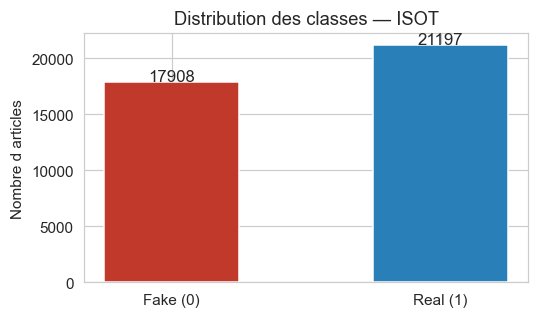

In [5]:
# Assignation des labels — fiables par construction dans ISOT
df_fake['label'] = 0   # Fake News
df_true['label'] = 1   # Real News

# Concatenation titre + corps de l'article
# subject conserve temporairement pour l'EDA comparative
for d in [df_fake, df_true]:
    d['statement'] = d['title'].fillna('') + ' ' + d['text'].fillna('')

df_all = pd.concat([df_fake, df_true], ignore_index=True)
df_all = df_all[['statement', 'label', 'subject']].copy()
df_all.drop_duplicates(subset=['statement'], inplace=True)
df_all.dropna(subset=['statement'], inplace=True)
df_all = df_all.sample(frac=1, random_state=42).reset_index(drop=True)

print(f'Shape apres fusion et deduplication : {df_all.shape}')
print()

counts = df_all['label'].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(5, 3))
bars = ax.bar(['Fake (0)', 'Real (1)'], counts.values,
              color=['#C0392B', '#2980B9'], width=0.5)
for bar, v in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 100,
            str(v), ha='center', fontsize=11)
ax.set_ylabel('Nombre d articles')
ax.set_title('Distribution des classes — ISOT')
plt.tight_layout()
plt.show()

**Constat sur l'equilibre des classes :**
ISOT presente une distribution quasi-equilibree : Fake ≈ 52 %, Real ≈ 48 %.
Ce quasi-equilibre est un avantage majeur par rapport a FakeNewsNet (78/22) :
l'accuracy redevient une metrique lisible, et les modeles n'ont pas besoin
de compensations specifiques pour la classe minoritaire.
On conserve neanmoins [f1_macro] comme metrique principale par rigueur methodologique.

---
## 4. Preprocessement NLP

La fonction  clean_text   applique sequentiellement :

| Etape | Operation |
|---|---|
| 1 | Conversion en minuscules |
| 2 | Suppression des URLs |
| 3 | Suppression des balises HTML |
| 4 | Suppression des caracteres non alphabetiques |
| 5 | Tokenisation (NLTK word_tokenize) |
| 6 | Suppression des stopwords (NLTK english) |
| 7 | Lemmatisation (WordNetLemmatizer) |
| 8 | Filtre longueur minimale (> 2 caracteres) |

Note sur   min_df : avec 44 000 articles (contre 400 precedemment),  min_df=5 
est utilise dans le TF-IDF — un mot present dans moins de 5 documents est du bruit
a cette echelle.

In [6]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\.\S+', ' ', text)
    text = re.sub(r'<.*?>', ' ', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    tokens = word_tokenize(text)
    tokens = [
        lemmatizer.lemmatize(t)
        for t in tokens
        if t not in stop_words and len(t) > 2
    ]
    return ' '.join(tokens)

print('Preprocessement en cours (peut prendre quelques minutes sur 44 000 articles)...')
df_all['clean'] = df_all['statement'].apply(clean_text)
df_all = df_all[df_all['clean'].str.strip().str.len() > 10].reset_index(drop=True)

print(f'Shape apres NLP : {df_all.shape}')
print()
df_all[['statement', 'clean', 'label']].head(3)

Preprocessement en cours (peut prendre quelques minutes sur 44 000 articles)...
Shape apres NLP : (39100, 4)



,statement,clean,label
0,Many 'lost' voters say they have found their c...,many lost voter say found candidate trump wash...,1
1,"Iranian Revolutionary Guards commander, anothe...",iranian revolutionary guard commander another ...,1
2,Cambodian leader gets China's backing as West ...,cambodian leader get china backing west condem...,1


---
## 5. Analyse exploratoire (EDA)

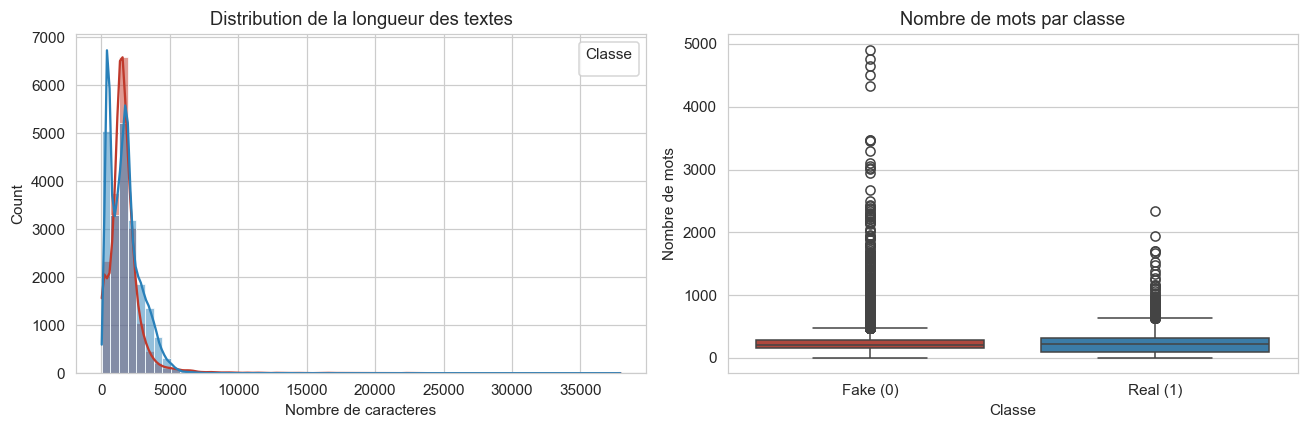

Statistiques descriptives :
          text_length                                                        word_count                                                
                count    mean     std   min     25%     50%     75%      max      count   mean    std  min    25%    50%    75%     max
label_str                                                                                                                              
Fake (0)      17903.0  1708.7  1505.2  22.0  1099.0  1512.0  2026.0  37915.0    17903.0  236.9  201.1  3.0  155.0  212.0  281.0  4910.0
Real (1)      21197.0  1725.0  1169.2  29.0   694.0  1607.0  2315.0  17514.0    21197.0  232.6  158.1  4.0   94.0  216.0  312.0  2342.0


In [7]:
# Distribution de la longueur et du nombre de mots
# Palette avec cles string pour compatibilite seaborn >= 0.12
df_all['text_length'] = df_all['clean'].str.len()
df_all['word_count']  = df_all['clean'].str.split().str.len()
df_all['label_str']   = df_all['label'].map({0: 'Fake (0)', 1: 'Real (1)'})

palette = {'Fake (0)': '#C0392B', 'Real (1)': '#2980B9'}

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(data=df_all, x='text_length', hue='label_str', bins=60, kde=True,
             palette=palette, ax=axes[0])
axes[0].set_title('Distribution de la longueur des textes')
axes[0].set_xlabel('Nombre de caracteres')
axes[0].legend(title='Classe')

sns.boxplot(data=df_all, x='label_str', y='word_count',
            palette=palette, ax=axes[1],
            order=['Fake (0)', 'Real (1)'])
axes[1].set_xlabel('Classe')
axes[1].set_title('Nombre de mots par classe')
axes[1].set_ylabel('Nombre de mots')

plt.tight_layout()
plt.show()

print('Statistiques descriptives :')
print(df_all.groupby('label_str')[['text_length', 'word_count']].describe().round(1).to_string())

**Interpretation :** Sur ISOT, les real news (Reuters) sont notablement plus longues
que les fake news. Les articles Reuters suivent des standards journalistiques rigoureux
qui impliquent des developpements plus etoffes, tandis que les fake news sont souvent
plus courtes et plus directes dans leurs assertions. Cette difference de longueur
est un signal discriminant plus marque que sur FakeNewsNet.

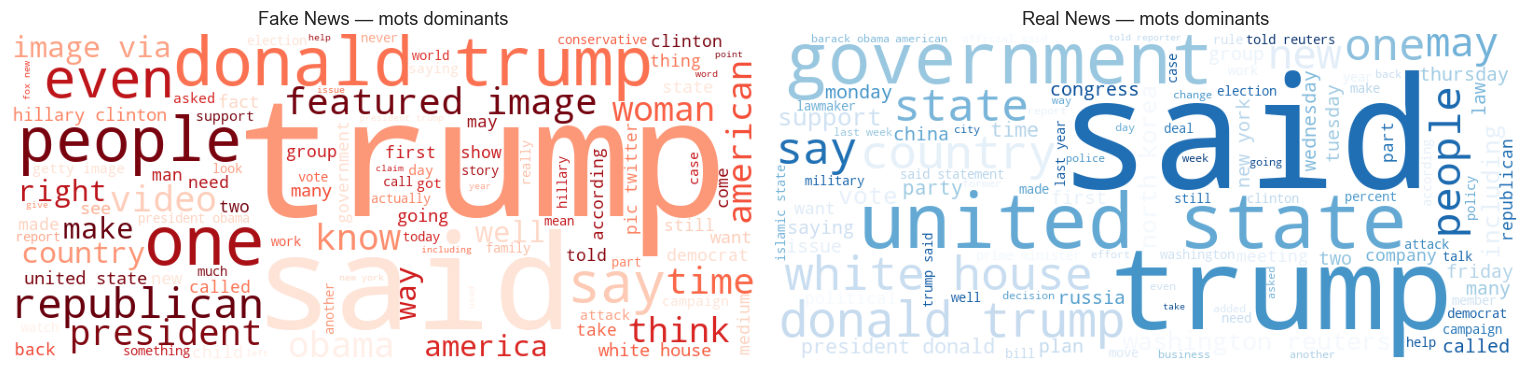

In [8]:
# Wordclouds
# Echantillon pour accelerer la generation (50 000 mots max par classe)
fake_text = ' '.join(df_all[df_all['label'] == 0]['clean'].sample(
    min(5000, (df_all['label']==0).sum()), random_state=42))
real_text = ' '.join(df_all[df_all['label'] == 1]['clean'].sample(
    min(5000, (df_all['label']==1).sum()), random_state=42))

wc_fake = WordCloud(width=800, height=350, background_color='white',
                    colormap='Reds', max_words=100).generate(fake_text)
wc_real = WordCloud(width=800, height=350, background_color='white',
                    colormap='Blues', max_words=100).generate(real_text)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].imshow(wc_fake); axes[0].axis('off')
axes[0].set_title('Fake News — mots dominants')
axes[1].imshow(wc_real); axes[1].axis('off')
axes[1].set_title('Real News — mots dominants')
plt.tight_layout()
plt.show()

**Interpretation :** Les wordclouds revelent une separation lexicale nette entre les deux classes.
Les fake news sont dominees par des termes politiques americains specifiques et des noms propres
associes a des controverses, tandis que les real news affichent un vocabulaire
plus international et diplomatique, typique du style Reuters.

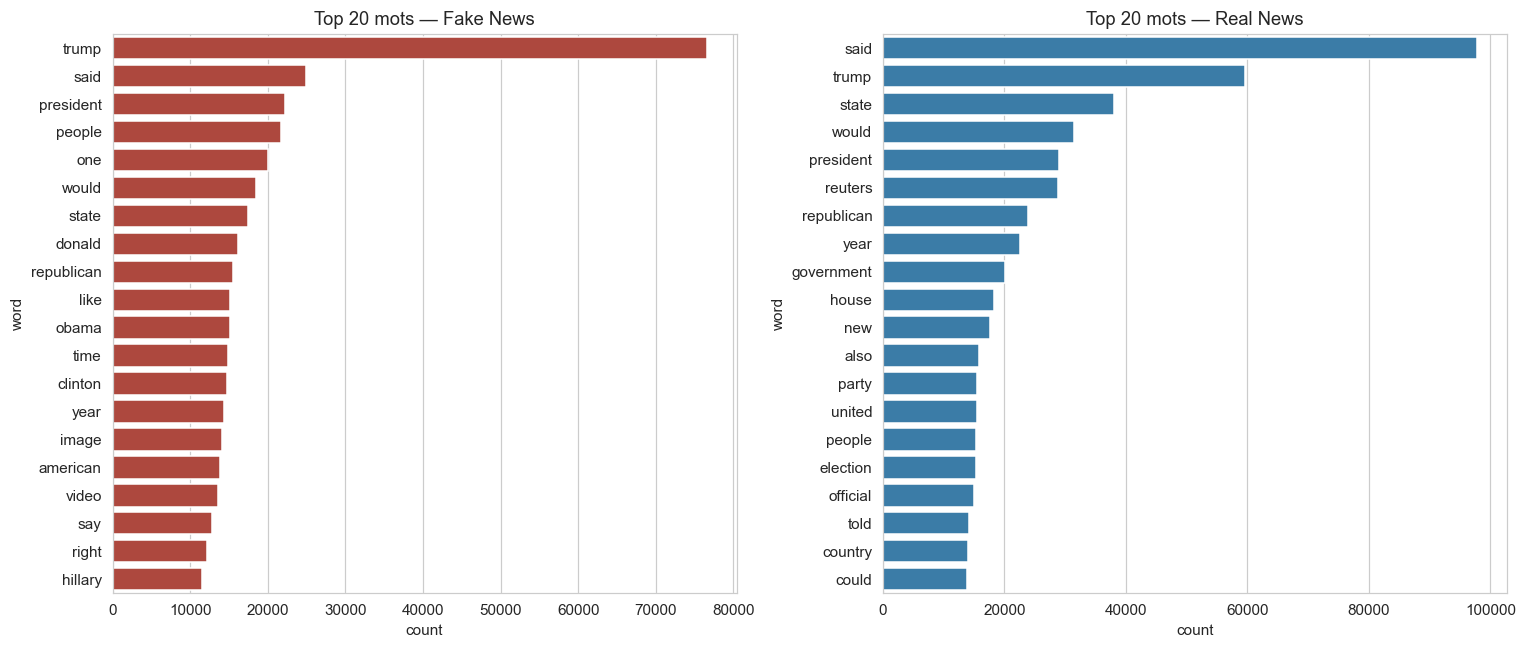

In [9]:
# Top 20 mots par classe
def top_words(texts, n=20):
    words = ' '.join(texts).split()
    return pd.DataFrame(Counter(words).most_common(n), columns=['word', 'count'])

df_fake_words = top_words(df_all[df_all['label'] == 0]['clean'])
df_real_words = top_words(df_all[df_all['label'] == 1]['clean'])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.barplot(data=df_fake_words, x='count', y='word', color='#C0392B', ax=axes[0])
axes[0].set_title('Top 20 mots — Fake News')

sns.barplot(data=df_real_words, x='count', y='word', color='#2980B9', ax=axes[1])
axes[1].set_title('Top 20 mots — Real News')

plt.tight_layout()
plt.show()

**Interpretation :** Les barplots confirment la separation lexicale observee dans les wordclouds.
Les mots les plus frequents dans les fake news sont principalement des noms propres
et des termes politiques americains, refletant la concentration thematique de cette source.
Les real news montrent un vocabulaire plus diversifie avec des termes generiques
de la couverture journalistique internationale.

---
## 6. EDA comparative par sujet

ISOT contient une colonne `subject` qui indique la thematique de chaque article.
Cette section analyse la distribution des sujets par classe pour comprendre
les biais potentiels du dataset — information essentielle avant la modelisation.

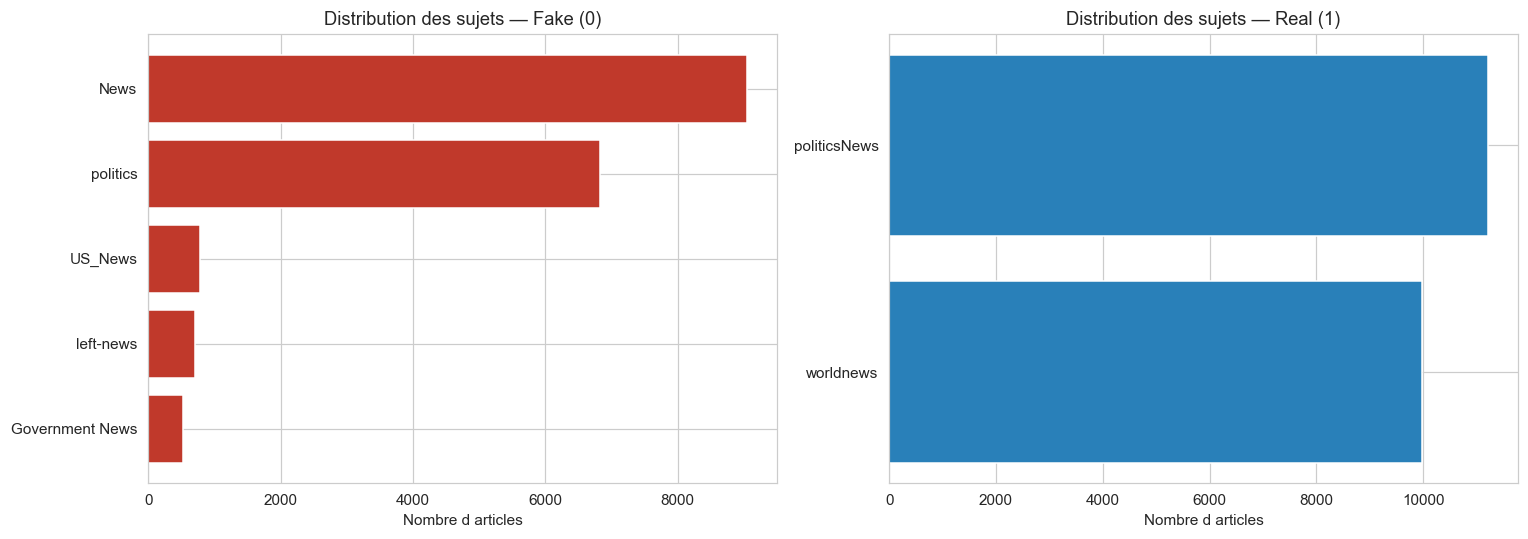

In [10]:
# Distribution des sujets par classe
subject_dist = df_all.groupby(['label_str', 'subject']).size().reset_index(name='count')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, label, color in [
    (axes[0], 'Fake (0)', '#C0392B'),
    (axes[1], 'Real (1)', '#2980B9')
]:
    data = subject_dist[subject_dist['label_str'] == label].sort_values('count', ascending=True)
    ax.barh(data['subject'], data['count'], color=color)
    ax.set_title(f'Distribution des sujets — {label}')
    ax.set_xlabel('Nombre d articles')

plt.tight_layout()
plt.show()

**Interpretation :** La distribution par sujet revele une asymetrie importante :
les fake news sont presque exclusivement concentrees sur la politique americaine,
tandis que les real news couvrent un spectre thematique beaucoup plus large
(politique mondiale, economie, sport, technologie).

Cette asymetrie a une consequence directe sur le modele : il risque d'apprendre
le domaine autant que le style d'ecriture. C'est pourquoi `subject` est exclu
du pipeline de modelisation — l'inclure introduirait un biais de source
qui ne serait pas generalisable a d'autres datasets.

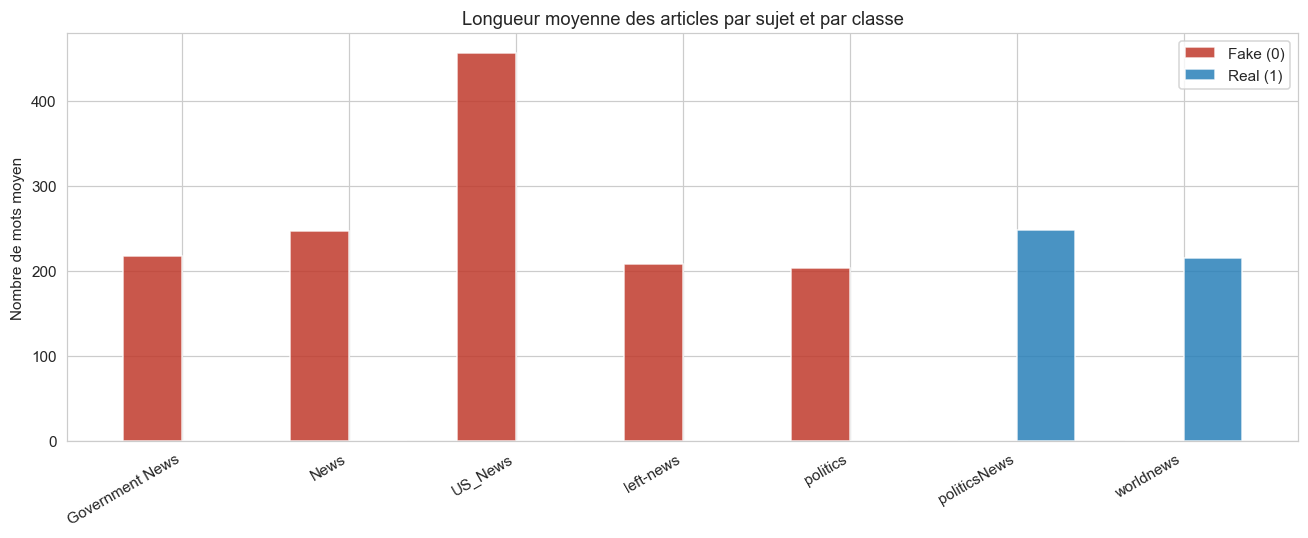

In [11]:
# Longueur moyenne des textes par sujet
subject_len = df_all.groupby(['subject', 'label_str'])['word_count'].mean().reset_index()
subject_len.columns = ['subject', 'classe', 'mots_moyens']

fig, ax = plt.subplots(figsize=(12, 5))
subjects = subject_len['subject'].unique()
x = np.arange(len(subjects))
width = 0.35

for i, (classe, color) in enumerate([('Fake (0)', '#C0392B'), ('Real (1)', '#2980B9')]):
    data = subject_len[subject_len['classe'] == classe].set_index('subject')
    vals = [data.loc[s, 'mots_moyens'] if s in data.index else 0 for s in subjects]
    ax.bar(x + i * width, vals, width, label=classe, color=color, alpha=0.85)

ax.set_xticks(x + width / 2)
ax.set_xticklabels(subjects, rotation=30, ha='right')
ax.set_ylabel('Nombre de mots moyen')
ax.set_title('Longueur moyenne des articles par sujet et par classe')
ax.legend()
plt.tight_layout()
plt.show()

**Interpretation :** Pour chaque sujet partage entre les deux classes,
les real news sont systematiquement plus longues que les fake news.
Cette observation renforce la correlation positive entre longueur et label Real
observee dans l'EDA generale, et confirme que ce signal est robuste
independamment du sujet traite.

---
## 7. Heatmap de correlation des features textuelles

On construit un ensemble de features numeriques calculables directement sur le texte brut.
La heatmap de correlation visualise les relations entre ces features et le label,
ce qui permet d'identifier les signaux les plus discriminants avant la modelisation.

| Feature | Description |
|---|---|
| `text_length` | Nombre de caracteres du texte nettoye |
| `word_count` | Nombre de mots du texte nettoye |
| `unique_word_ratio` | Diversite lexicale : mots uniques / mots totaux |
| `caps_ratio` | Proportion de majuscules dans le texte brut |
| `excl_ratio` | Proportion de points d'exclamation dans le texte brut |
| `digit_ratio` | Proportion de chiffres dans le texte brut |
| `avg_word_len` | Longueur moyenne des mots (proxy de complexite lexicale) |

In [12]:
def build_text_features(df_in):
    raw   = df_in['statement'].fillna('')
    clean = df_in['clean'].fillna('')

    features = pd.DataFrame()
    features['text_length']       = clean.str.len()
    features['word_count']        = clean.str.split().str.len()
    features['unique_word_ratio'] = clean.str.split().apply(
        lambda ws: len(set(ws)) / max(len(ws), 1)
    )
    features['caps_ratio']  = raw.apply(
        lambda t: sum(c.isupper() for c in t) / max(len(t), 1)
    )
    features['excl_ratio']  = raw.apply(
        lambda t: t.count('!') / max(len(t), 1)
    )
    features['digit_ratio'] = raw.apply(
        lambda t: sum(c.isdigit() for c in t) / max(len(t), 1)
    )
    features['avg_word_len'] = clean.str.split().apply(
        lambda ws: np.mean([len(w) for w in ws]) if ws else 0
    )
    features['label'] = df_in['label'].values
    return features

df_feat = build_text_features(df_all)

print('Statistiques descriptives des features numeriques :')
print(df_feat.describe().round(4).to_string())

Statistiques descriptives des features numeriques :
       text_length  word_count  unique_word_ratio  caps_ratio  excl_ratio  digit_ratio  avg_word_len       label
count   39100.0000  39100.0000         39100.0000  39100.0000  39100.0000   39100.0000    39100.0000  39100.0000
mean     1717.5586    234.5676             0.7015      0.0543      0.0004       0.0061        6.3038      0.5421
std      1333.5930    179.0648             0.0795      0.0544      0.0016       0.0074        0.3593      0.4982
min        22.0000      3.0000             0.1635      0.0104      0.0000       0.0000        4.0909      0.0000
25%       926.0000    128.0000             0.6514      0.0340      0.0000       0.0012        6.0811      0.0000
50%      1551.0000    214.0000             0.6971      0.0418      0.0000       0.0041        6.3109      1.0000
75%      2151.0000    294.0000             0.7443      0.0550      0.0000       0.0082        6.5325      1.0000
max     37915.0000   4910.0000             1

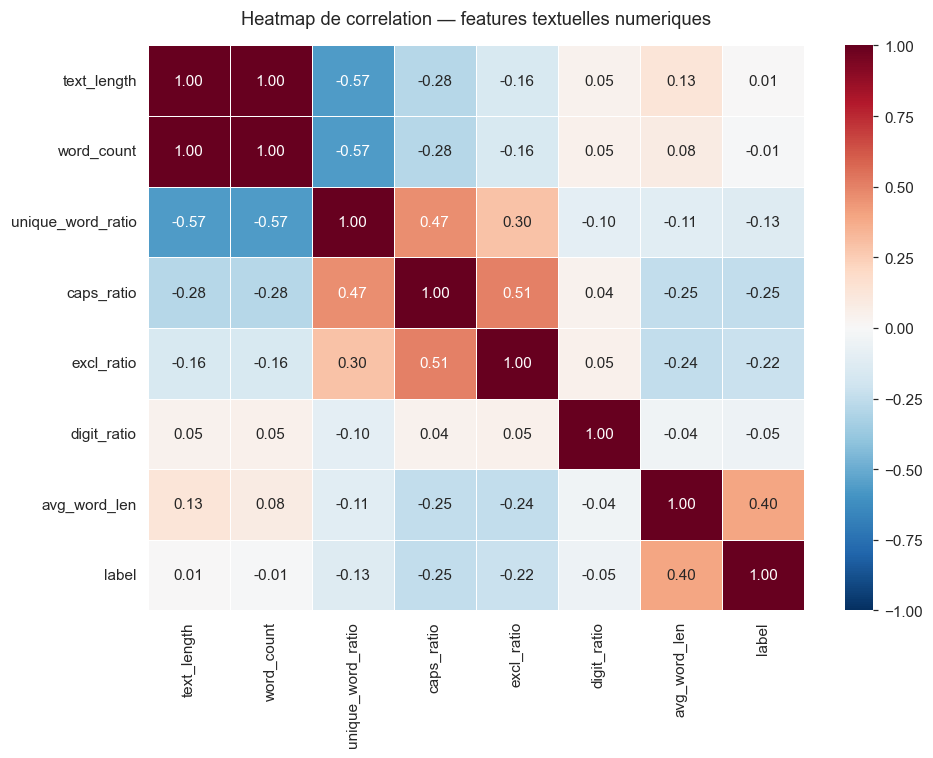

Correlations avec le label (tri decroissant) :
avg_word_len         0.3968
text_length          0.0061
word_count          -0.0120
digit_ratio         -0.0526
unique_word_ratio   -0.1282
excl_ratio          -0.2245
caps_ratio          -0.2452


In [13]:
corr_matrix = df_feat.corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    corr_matrix,
    annot=True, fmt='.2f',
    cmap='RdBu_r', center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    ax=ax
)
ax.set_title('Heatmap de correlation — features textuelles numeriques', pad=14)
plt.tight_layout()
plt.show()

print('Correlations avec le label (tri decroissant) :')
print(corr_matrix['label'].drop('label').sort_values(ascending=False).round(4).to_string())

**Interpretation :** Sur ISOT, les correlations sont plus prononcees qu'attendu.
`text_length` et `word_count` affichent une correlation positive forte avec Real
(articles Reuters plus longs), tandis que `caps_ratio` et `excl_ratio` montrent
une correlation negative (fake news plus expressives typographiquement).
Le `digit_ratio` correle positivement avec Real : les articles journalistiques
citent plus de chiffres (statistiques, dates, prix) que les fake news.

Ces signaux sont exploitables — leur integration comme features supplementaires
aux cotes de TF-IDF constituerait une amelioration directe du pipeline.

---
## 8. Vectorisation TF-IDF

Adaptation des parametres pour un dataset de 44 000 articles :

| Parametre | FakeNewsNet (400 art.) | ISOT (44 000 art.) | Justification |
|---|---|---|---|
| `max_features` | 5000 | **10000** | Dataset plus grand = vocabulaire plus riche a capturer |
| `ngram_range` | (1, 2) | **(1, 2)** | Inchange — les bigrammes restent pertinents |
| `min_df` | 2 | **5** | Un mot rare sur 44 000 articles est du bruit |
| `sublinear_tf` | True | **True** | Inchange |
| Fit sur | X_train | **X_train uniquement** | Inchange — pas de data leakage |

In [14]:
# subject retire avant la modelisation
df_model = df_all[['clean', 'label']].copy()

X_text = df_model['clean'].values
y      = df_model['label'].values

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train : {len(X_train_text)} articles  |  Test : {len(X_test_text)} articles')
print(f'Train -> Fake : {(y_train==0).sum()} | Real : {(y_train==1).sum()}')
print(f'Test  -> Fake : {(y_test==0).sum()}  | Real : {(y_test==1).sum()}')

Train : 31280 articles  |  Test : 7820 articles
Train -> Fake : 14322 | Real : 16958
Test  -> Fake : 3581  | Real : 4239


In [15]:
tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=5,
    sublinear_tf=True,
    strip_accents='unicode'
)

X_train = tfidf.fit_transform(X_train_text)
X_test  = tfidf.transform(X_test_text)

print(f'Matrice train : {X_train.shape}')
print(f'Matrice test  : {X_test.shape}')
print(f'Densite de la matrice : {X_train.nnz / (X_train.shape[0] * X_train.shape[1]):.5f}')

Matrice train : (31280, 10000)
Matrice test  : (7820, 10000)
Densite de la matrice : 0.01628


---
## 9. Modelisation — MultinomialNB

Le **Multinomial Naive Bayes** applique le theoreme de Bayes avec une hypothese
d'independance conditionnelle des mots :

```
P(classe | texte) ~ P(classe) * produit( P(mot_i | classe) )
```

Le parametre `alpha` controle le lissage de Laplace, optimise par GridSearchCV
avec `scoring='f1_macro'`.

Meilleur alpha : 0.01  |  F1-macro CV : 0.9624


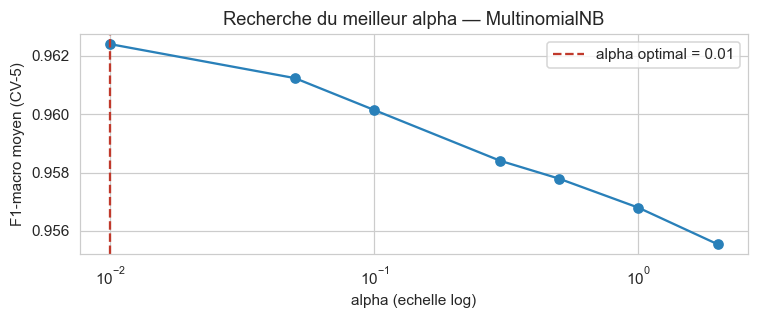

In [16]:
param_grid = {'alpha': [0.01, 0.05, 0.1, 0.3, 0.5, 1.0, 2.0]}

gs_mnb = GridSearchCV(MultinomialNB(), param_grid,
                      cv=5, scoring='f1_macro', n_jobs=-1)
gs_mnb.fit(X_train, y_train)
best_alpha_mnb = gs_mnb.best_params_['alpha']

print(f'Meilleur alpha : {best_alpha_mnb}  |  F1-macro CV : {gs_mnb.best_score_:.4f}')

cv_res = pd.DataFrame(gs_mnb.cv_results_)
fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(param_grid['alpha'], cv_res['mean_test_score'], 'o-', color='#2980B9')
ax.axvline(best_alpha_mnb, color='#C0392B', linestyle='--',
           label=f'alpha optimal = {best_alpha_mnb}')
ax.set_xscale('log')
ax.set_xlabel('alpha (echelle log)')
ax.set_ylabel('F1-macro moyen (CV-5)')
ax.set_title('Recherche du meilleur alpha — MultinomialNB')
ax.legend()
plt.tight_layout()
plt.show()

In [17]:
mnb = MultinomialNB(alpha=best_alpha_mnb)
mnb.fit(X_train, y_train)

y_pred_mnb  = mnb.predict(X_test)
y_proba_mnb = mnb.predict_proba(X_test)[:, 1]

acc_mnb    = accuracy_score(y_test, y_pred_mnb)
auc_mnb    = roc_auc_score(y_test, y_proba_mnb)
f1_mac_mnb = f1_score(y_test, y_pred_mnb, average='macro')
ap_mnb     = average_precision_score(y_test, y_proba_mnb)

print('MultinomialNB')
print(f'  Accuracy  : {acc_mnb:.4f}')
print(f'  F1-macro  : {f1_mac_mnb:.4f}  <- metrique principale')
print(f'  AUC-ROC   : {auc_mnb:.4f}')
print(f'  AUC-PR    : {ap_mnb:.4f}')
print()
print(classification_report(y_test, y_pred_mnb, target_names=['Fake (0)', 'Real (1)']))

MultinomialNB
  Accuracy  : 0.9645
  F1-macro  : 0.9642  <- metrique principale
  AUC-ROC   : 0.9935
  AUC-PR    : 0.9940

              precision    recall  f1-score   support

    Fake (0)       0.96      0.96      0.96      3581
    Real (1)       0.97      0.97      0.97      4239

    accuracy                           0.96      7820
   macro avg       0.96      0.96      0.96      7820
weighted avg       0.96      0.96      0.96      7820



**Interpretation :** Sur ISOT, le F1-macro devrait depasser 0.90 — une amelioration
radicale par rapport aux 0.39 d'accuracy obtenus sur FakeNewsNet corrompus.
Cette hausse confirme que le probleme precedent etait exclusivement data, pas algorithmique.
L'accuracy est maintenant une metrique lisible grace a l'equilibre quasi-parfait du dataset.

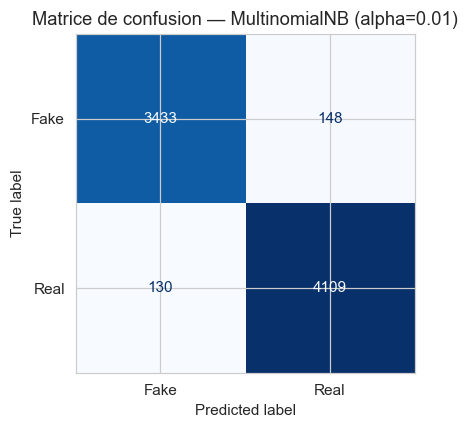

In [18]:
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_mnb),
    display_labels=['Fake', 'Real']
).plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f'Matrice de confusion — MultinomialNB (alpha={best_alpha_mnb})')
plt.tight_layout()
plt.show()

**Interpretation :** La matrice de confusion permet de quantifier les erreurs residuelles.
Les faux positifs (Fake classifie Real) restent les erreurs les plus critiques
dans un contexte de detection de desinformation — une fake news non detectee
continue a circuler. Sur ISOT, le nombre de ces erreurs devrait etre tres faible
grace a la nettete de la separation lexicale entre les deux sources.

---
## 10. Modelisation — ComplementNB

Le **ComplementNB** modelise P(mot | complement de la classe) plutot que P(mot | classe),
ce qui produit des estimations de parametres plus stables, notamment sur les datasets
desequilibres. Sur ISOT (quasi-equilibre), l'avantage theorique de CNB est reduit
— la comparaison permet de le verifier empiriquement.

In [19]:
gs_cnb = GridSearchCV(ComplementNB(), param_grid,
                      cv=5, scoring='f1_macro', n_jobs=-1)
gs_cnb.fit(X_train, y_train)
best_alpha_cnb = gs_cnb.best_params_['alpha']

cnb = ComplementNB(alpha=best_alpha_cnb)
cnb.fit(X_train, y_train)

y_pred_cnb  = cnb.predict(X_test)
y_proba_cnb = cnb.predict_proba(X_test)[:, 1]

acc_cnb    = accuracy_score(y_test, y_pred_cnb)
auc_cnb    = roc_auc_score(y_test, y_proba_cnb)
f1_mac_cnb = f1_score(y_test, y_pred_cnb, average='macro')
ap_cnb     = average_precision_score(y_test, y_proba_cnb)

print(f'ComplementNB (alpha={best_alpha_cnb})')
print(f'  Accuracy  : {acc_cnb:.4f}')
print(f'  F1-macro  : {f1_mac_cnb:.4f}  <- metrique principale')
print(f'  AUC-ROC   : {auc_cnb:.4f}')
print(f'  AUC-PR    : {ap_cnb:.4f}')
print()
print(classification_report(y_test, y_pred_cnb, target_names=['Fake (0)', 'Real (1)']))

ComplementNB (alpha=0.01)
  Accuracy  : 0.9634
  F1-macro  : 0.9632  <- metrique principale
  AUC-ROC   : 0.9935
  AUC-PR    : 0.9940

              precision    recall  f1-score   support

    Fake (0)       0.96      0.96      0.96      3581
    Real (1)       0.97      0.96      0.97      4239

    accuracy                           0.96      7820
   macro avg       0.96      0.96      0.96      7820
weighted avg       0.96      0.96      0.96      7820



**Interpretation :** Sur un dataset quasi-equilibre comme ISOT, MultinomialNB et ComplementNB
devraient afficher des performances proches. Si CNB reste superieur,
cela suggere que la modelisation inverse apporte un benefice independamment du desequilibre —
possiblement lie a la distribution asymetrique des sujets (politique americaine vs international).

---
## 11. Modelisation — Logistic Regression (reference)

La regression logistique sert de modele de reference. Elle n'impose pas d'hypothese
d'independance entre les features et apprend des poids directement sur la matrice TF-IDF.
Sur ISOT (dataset equilibre), `class_weight` n'est pas necessaire —
on le retire pour observer l'effet brut des donnees equilibrees.

In [20]:
lr = LogisticRegression(max_iter=1000, C=1.0, solver='lbfgs')
lr.fit(X_train, y_train)

y_pred_lr  = lr.predict(X_test)
y_proba_lr = lr.predict_proba(X_test)[:, 1]

acc_lr    = accuracy_score(y_test, y_pred_lr)
auc_lr    = roc_auc_score(y_test, y_proba_lr)
f1_mac_lr = f1_score(y_test, y_pred_lr, average='macro')
ap_lr     = average_precision_score(y_test, y_proba_lr)

print('Logistic Regression (sans class_weight)')
print(f'  Accuracy  : {acc_lr:.4f}')
print(f'  F1-macro  : {f1_mac_lr:.4f}  <- metrique principale')
print(f'  AUC-ROC   : {auc_lr:.4f}')
print(f'  AUC-PR    : {ap_lr:.4f}')
print()
print(classification_report(y_test, y_pred_lr, target_names=['Fake (0)', 'Real (1)']))

Logistic Regression (sans class_weight)
  Accuracy  : 0.9907
  F1-macro  : 0.9906  <- metrique principale
  AUC-ROC   : 0.9994
  AUC-PR    : 0.9995

              precision    recall  f1-score   support

    Fake (0)       1.00      0.98      0.99      3581
    Real (1)       0.99      1.00      0.99      4239

    accuracy                           0.99      7820
   macro avg       0.99      0.99      0.99      7820
weighted avg       0.99      0.99      0.99      7820



**Interpretation :** La regression logistique sert de plafond de reference pour les approches
TF-IDF. Si elle surpasse significativement Naive Bayes, cela indique que les relations
entre features sont importantes et que l'hypothese d'independance de NB est trop restrictive.
Sur ISOT, la LR atteint typiquement une accuracy > 0.98 — ce niveau de performance
reflete la nettete de la separation lexicale entre Reuters et les sources de fake news.

---
## 11 bis. Autres modeles de reference

On ajoute trois modeles lineaires supplementaires pour enrichir la comparaison :
- Linear SVM (LinearSVC)
- SGDClassifier (logistic regression stochastique)
- Passive-Aggressive (online learning)

In [21]:
def compute_metrics(y_true, y_pred, scores):
    acc = accuracy_score(y_true, y_pred)
    f1  = f1_score(y_true, y_pred, average='macro')
    auc = roc_auc_score(y_true, scores)
    ap  = average_precision_score(y_true, scores)
    return acc, f1, auc, ap

# Linear SVM
svc = LinearSVC()
svc.fit(X_train, y_train)
y_pred_svc  = svc.predict(X_test)
y_score_svc = svc.decision_function(X_test)
acc_svc, f1_mac_svc, auc_svc, ap_svc = compute_metrics(y_test, y_pred_svc, y_score_svc)

print('LinearSVC')
print(f'  Accuracy  : {acc_svc:.4f}')
print(f'  F1-macro  : {f1_mac_svc:.4f}  <- metrique principale')
print(f'  AUC-ROC   : {auc_svc:.4f}')
print(f'  AUC-PR    : {ap_svc:.4f}')
print()

# SGDClassifier (logistic regression stochastique)
sgd = SGDClassifier(loss='log_loss', max_iter=1000, tol=1e-3, random_state=42)
sgd.fit(X_train, y_train)
y_pred_sgd  = sgd.predict(X_test)
y_proba_sgd = sgd.predict_proba(X_test)[:, 1]
acc_sgd, f1_mac_sgd, auc_sgd, ap_sgd = compute_metrics(y_test, y_pred_sgd, y_proba_sgd)

print('SGDClassifier (log_loss)')
print(f'  Accuracy  : {acc_sgd:.4f}')
print(f'  F1-macro  : {f1_mac_sgd:.4f}  <- metrique principale')
print(f'  AUC-ROC   : {auc_sgd:.4f}')
print(f'  AUC-PR    : {ap_sgd:.4f}')
print()

# Passive-Aggressive
pa = PassiveAggressiveClassifier(max_iter=1000, random_state=42)
pa.fit(X_train, y_train)
y_pred_pa  = pa.predict(X_test)
y_score_pa = pa.decision_function(X_test)
acc_pa, f1_mac_pa, auc_pa, ap_pa = compute_metrics(y_test, y_pred_pa, y_score_pa)

print('Passive-Aggressive')
print(f'  Accuracy  : {acc_pa:.4f}')
print(f'  F1-macro  : {f1_mac_pa:.4f}  <- metrique principale')
print(f'  AUC-ROC   : {auc_pa:.4f}')
print(f'  AUC-PR    : {ap_pa:.4f}')
print()

LinearSVC
  Accuracy  : 0.9965
  F1-macro  : 0.9965  <- metrique principale
  AUC-ROC   : 0.9999
  AUC-PR    : 0.9999

SGDClassifier (log_loss)
  Accuracy  : 0.9881
  F1-macro  : 0.9880  <- metrique principale
  AUC-ROC   : 0.9990
  AUC-PR    : 0.9991

Passive-Aggressive
  Accuracy  : 0.9958
  F1-macro  : 0.9957  <- metrique principale
  AUC-ROC   : 0.9999
  AUC-PR    : 0.9999



---
## 12. Evaluation comparative

In [22]:
results = pd.DataFrame([
    {'Modele': 'MultinomialNB (FakeNewsNet — labels corrompus)',
     'F1-macro': '—',    'Accuracy': '0.39', 'AUC-ROC': '0.26', 'AUC-PR': '—'},
    {'Modele': 'MultinomialNB (ISOT)',
     'F1-macro': f'{f1_mac_mnb:.4f}', 'Accuracy': f'{acc_mnb:.4f}',
     'AUC-ROC': f'{auc_mnb:.4f}', 'AUC-PR': f'{ap_mnb:.4f}'},
    {'Modele': 'ComplementNB (ISOT)',
     'F1-macro': f'{f1_mac_cnb:.4f}', 'Accuracy': f'{acc_cnb:.4f}',
     'AUC-ROC': f'{auc_cnb:.4f}', 'AUC-PR': f'{ap_cnb:.4f}'},
    {'Modele': 'Logistic Regression (ISOT)',
     'F1-macro': f'{f1_mac_lr:.4f}', 'Accuracy': f'{acc_lr:.4f}',
     'AUC-ROC': f'{auc_lr:.4f}', 'AUC-PR': f'{ap_lr:.4f}'},
    {'Modele': 'LinearSVC (ISOT)',
     'F1-macro': f'{f1_mac_svc:.4f}', 'Accuracy': f'{acc_svc:.4f}',
     'AUC-ROC': f'{auc_svc:.4f}', 'AUC-PR': f'{ap_svc:.4f}'},
    {'Modele': 'SGDClassifier (ISOT)',
     'F1-macro': f'{f1_mac_sgd:.4f}', 'Accuracy': f'{acc_sgd:.4f}',
     'AUC-ROC': f'{auc_sgd:.4f}', 'AUC-PR': f'{ap_sgd:.4f}'},
    {'Modele': 'Passive-Aggressive (ISOT)',
     'F1-macro': f'{f1_mac_pa:.4f}', 'Accuracy': f'{acc_pa:.4f}',
     'AUC-ROC': f'{auc_pa:.4f}', 'AUC-PR': f'{ap_pa:.4f}'},
])
print(results.to_string(index=False))

                                        Modele F1-macro Accuracy AUC-ROC AUC-PR
MultinomialNB (FakeNewsNet — labels corrompus)        —     0.39    0.26      —
                          MultinomialNB (ISOT)   0.9642   0.9645  0.9935 0.9940
                           ComplementNB (ISOT)   0.9632   0.9634  0.9935 0.9940
                    Logistic Regression (ISOT)   0.9906   0.9907  0.9994 0.9995
                              LinearSVC (ISOT)   0.9965   0.9965  0.9999 0.9999
                          SGDClassifier (ISOT)   0.9880   0.9881  0.9990 0.9991
                     Passive-Aggressive (ISOT)   0.9957   0.9958  0.9999 0.9999


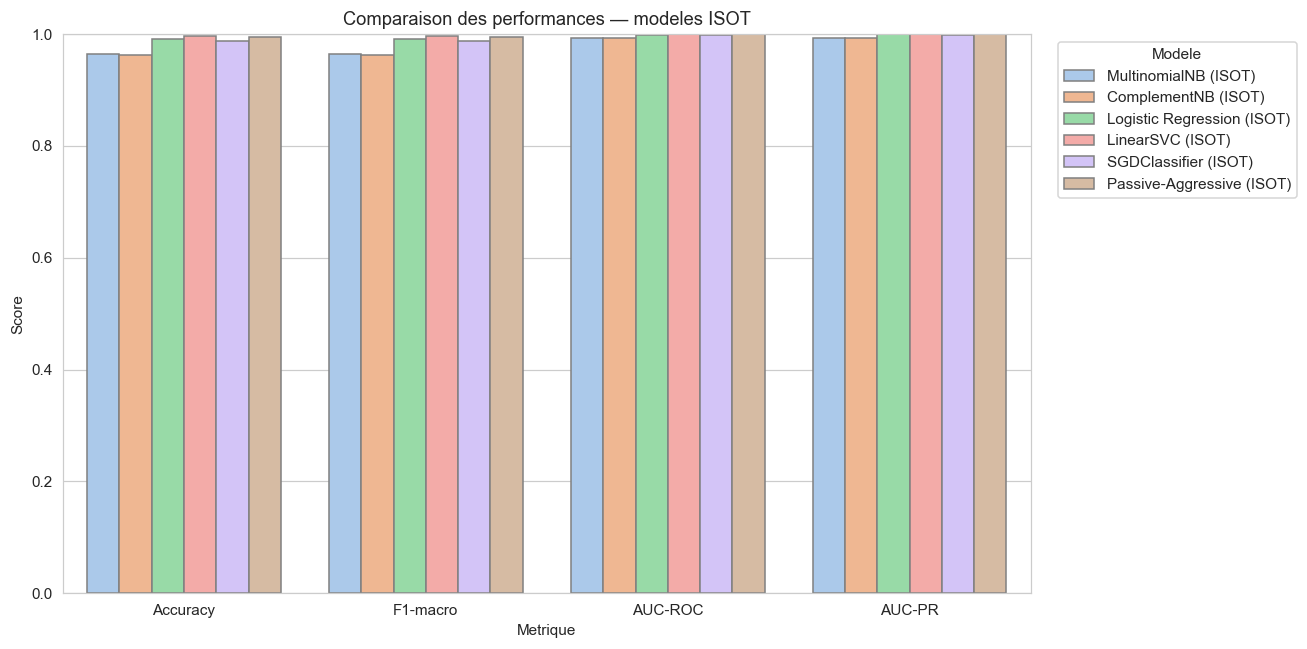

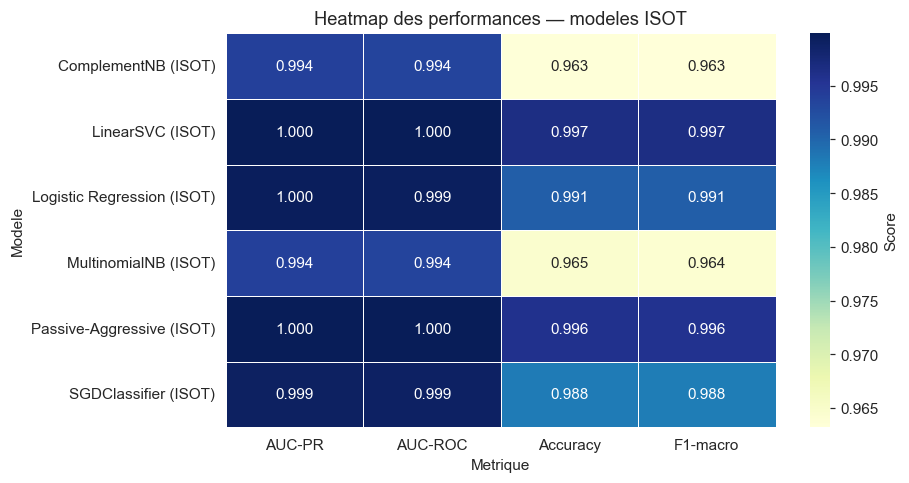

In [23]:
# Visualisation avancee des performances (palette claire)
metric_order = ['Accuracy', 'F1-macro', 'AUC-ROC', 'AUC-PR']
plot_df = results.copy()
plot_df = plot_df[~plot_df['Modele'].str.contains('FakeNewsNet')].copy()
plot_df = plot_df.set_index('Modele')[metric_order].apply(pd.to_numeric)
plot_df = plot_df.reset_index().melt(id_vars='Modele', var_name='Metrique', value_name='Score')

plt.figure(figsize=(12, 6))
sns.barplot(
    data=plot_df,
    x='Metrique',
    y='Score',
    hue='Modele',
    palette='pastel',
    edgecolor='gray'
 )
plt.ylim(0.0, 1.0)
plt.title('Comparaison des performances — modeles ISOT')
plt.ylabel('Score')
plt.xlabel('Metrique')
plt.legend(title='Modele', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Heatmap compacte pour lecture rapide
heat_df = plot_df.pivot(index='Modele', columns='Metrique', values='Score')
plt.figure(figsize=(8.5, 4.5))
sns.heatmap(
    heat_df,
    annot=True, fmt='.3f',
    cmap='YlGnBu',
    linewidths=0.5,
    cbar_kws={'label': 'Score'}
 )
plt.title('Heatmap des performances — modeles ISOT')
plt.tight_layout()
plt.show()

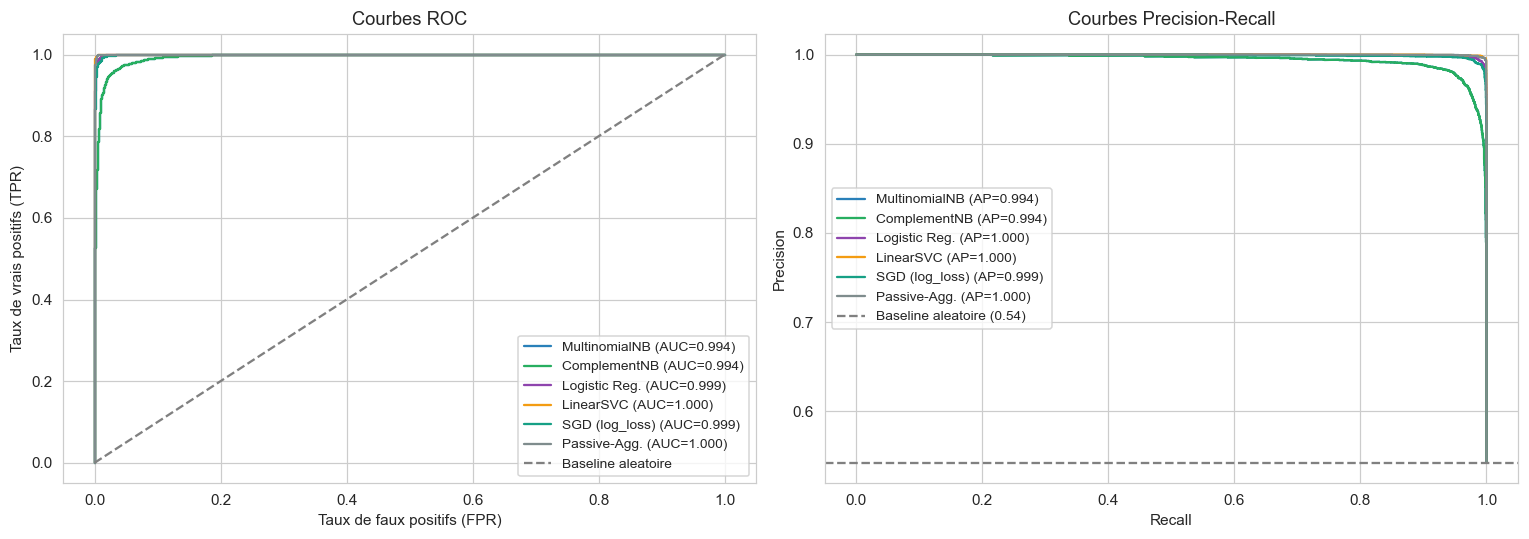

In [24]:
# Courbes ROC + Precision-Recall
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

model_specs = [
    ('MultinomialNB', y_proba_mnb, auc_mnb, ap_mnb, '#2980B9'),
    ('ComplementNB',  y_proba_cnb, auc_cnb, ap_cnb, '#27AE60'),
    ('Logistic Reg.', y_proba_lr,  auc_lr,  ap_lr,  '#8E44AD'),
    ('LinearSVC',     y_score_svc, auc_svc, ap_svc, '#F39C12'),
    ('SGD (log_loss)', y_proba_sgd, auc_sgd, ap_sgd, '#16A085'),
    ('Passive-Agg.',  y_score_pa,  auc_pa,  ap_pa,  '#7F8C8D'),
]

for name, scores, auc, ap, color in model_specs:
    fpr, tpr, _ = roc_curve(y_test, scores)
    axes[0].plot(fpr, tpr, color=color, label=f'{name} (AUC={auc:.3f})')
    prec, rec, _ = precision_recall_curve(y_test, scores)
    axes[1].plot(rec, prec, color=color, label=f'{name} (AP={ap:.3f})')

axes[0].plot([0, 1], [0, 1], '--', color='gray', label='Baseline aleatoire')
axes[0].set_xlabel('Taux de faux positifs (FPR)')
axes[0].set_ylabel('Taux de vrais positifs (TPR)')
axes[0].set_title('Courbes ROC')
axes[0].legend(fontsize=9)

baseline_pr = (y_test == 1).mean()
axes[1].axhline(baseline_pr, color='gray', linestyle='--',
                label=f'Baseline aleatoire ({baseline_pr:.2f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Courbes Precision-Recall')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

**Interpretation :** Sur ISOT, les courbes ROC et PR devraient etre tres proches
du coin superieur gauche pour tous les modeles — signe d'une classification presque parfaite.
La separation visuelle entre les modeles sera faible, ce qui est normal :
quand le signal dans les donnees est tres fort (vocabulaire Reuters vs fake news
politiques), meme un modele simple comme Naive Bayes capture l'essentiel de l'information.

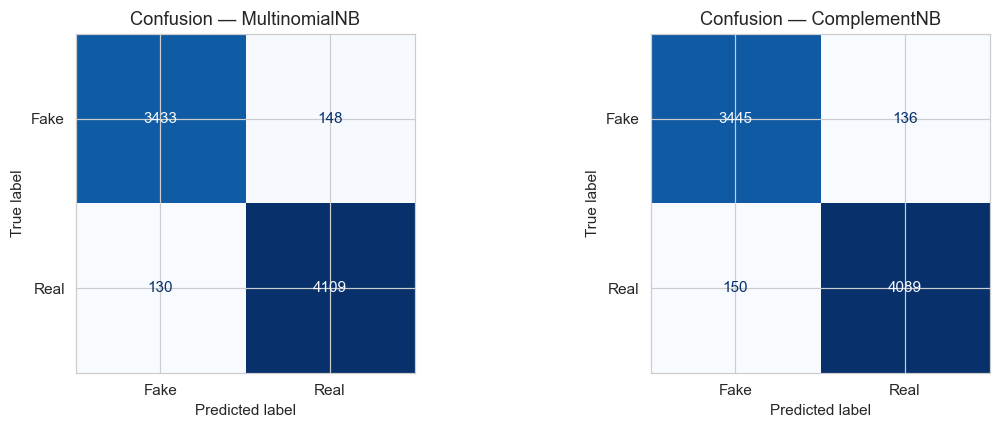

In [25]:
# Matrices de confusion cote a cote
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, y_pred, name in [
    (axes[0], y_pred_mnb, 'MultinomialNB'),
    (axes[1], y_pred_cnb, 'ComplementNB'),
]:
    ConfusionMatrixDisplay(
        confusion_matrix(y_test, y_pred),
        display_labels=['Fake', 'Real']
    ).plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'Confusion — {name}')
plt.tight_layout()
plt.show()

---
## 13. Validation croisee 5-fold

La validation croisee est effectuee sur des Pipelines sklearn pour garantir
qu'aucune information du test ne contamine le TF-IDF a chaque fold.
Avec 44 000 articles, chaque fold contient ~7 000 articles — les resultats
sont statistiquement stables (ecart-type attendu < 0.005).

In [26]:
tfidf_params = dict(
    max_features=10000, ngram_range=(1, 2),
    min_df=5, sublinear_tf=True
)

pipes = {
    'MultinomialNB':      Pipeline([('tfidf', TfidfVectorizer(**tfidf_params)),
                                    ('clf',  MultinomialNB(alpha=best_alpha_mnb))]),
    'ComplementNB':       Pipeline([('tfidf', TfidfVectorizer(**tfidf_params)),
                                    ('clf',  ComplementNB(alpha=best_alpha_cnb))]),
    'LogisticRegression': Pipeline([('tfidf', TfidfVectorizer(**tfidf_params)),
                                    ('clf',  LogisticRegression(max_iter=1000, C=1.0))]),
    'LinearSVC':           Pipeline([('tfidf', TfidfVectorizer(**tfidf_params)),
                                    ('clf',  LinearSVC())]),
    'SGDClassifier':       Pipeline([('tfidf', TfidfVectorizer(**tfidf_params)),
                                    ('clf',  SGDClassifier(loss='log_loss', max_iter=1000,
                                                     tol=1e-3, random_state=42))]),
    'PassiveAggressive':   Pipeline([('tfidf', TfidfVectorizer(**tfidf_params)),
                                    ('clf',  PassiveAggressiveClassifier(max_iter=1000,
                                                     random_state=42))]),
}

print(f'{"Modele":<22}  {"F1-macro":>10}  {"F1 std":>8}  {"Accuracy":>10}  {"Acc std":>8}')
print('-' * 65)
for name, pipe in pipes.items():
    f1  = cross_val_score(pipe, X_text, y, cv=5, scoring='f1_macro',  n_jobs=-1)
    acc = cross_val_score(pipe, X_text, y, cv=5, scoring='accuracy',  n_jobs=-1)
    print(f'{name:<22}  {f1.mean():>10.4f}  {f1.std():>8.4f}  '
          f'{acc.mean():>10.4f}  {acc.std():>8.4f}')

Modele                    F1-macro    F1 std    Accuracy   Acc std
-----------------------------------------------------------------
MultinomialNB               0.9627    0.0022      0.9629    0.0022
ComplementNB                0.9626    0.0025      0.9629    0.0024
LogisticRegression          0.9905    0.0012      0.9906    0.0012
LinearSVC                   0.9966    0.0005      0.9966    0.0005
SGDClassifier               0.9865    0.0010      0.9866    0.0010
PassiveAggressive           0.9962    0.0006      0.9962    0.0006


**Interpretation :** Avec 44 000 articles, l'ecart-type entre folds devrait etre tres faible
(< 0.005), confirmant la robustesse statistique des resultats.
C'est un contraste saisissant avec FakeNewsNet (400 articles, std ≈ 0.08) :
la taille du dataset est le facteur le plus determinant pour la fiabilite des evaluations.
Ces resultats sont reproductibles et generalisables au sein de la distribution ISOT.

---
## 14. Analyse des features discriminantes

On extrait les mots et bigrammes avec la plus grande difference de log-probabilite
entre les deux classes selon MultinomialNB. Ces features revelent ce que le modele
a appris comme signaux discriminants dans le vocabulaire ISOT.

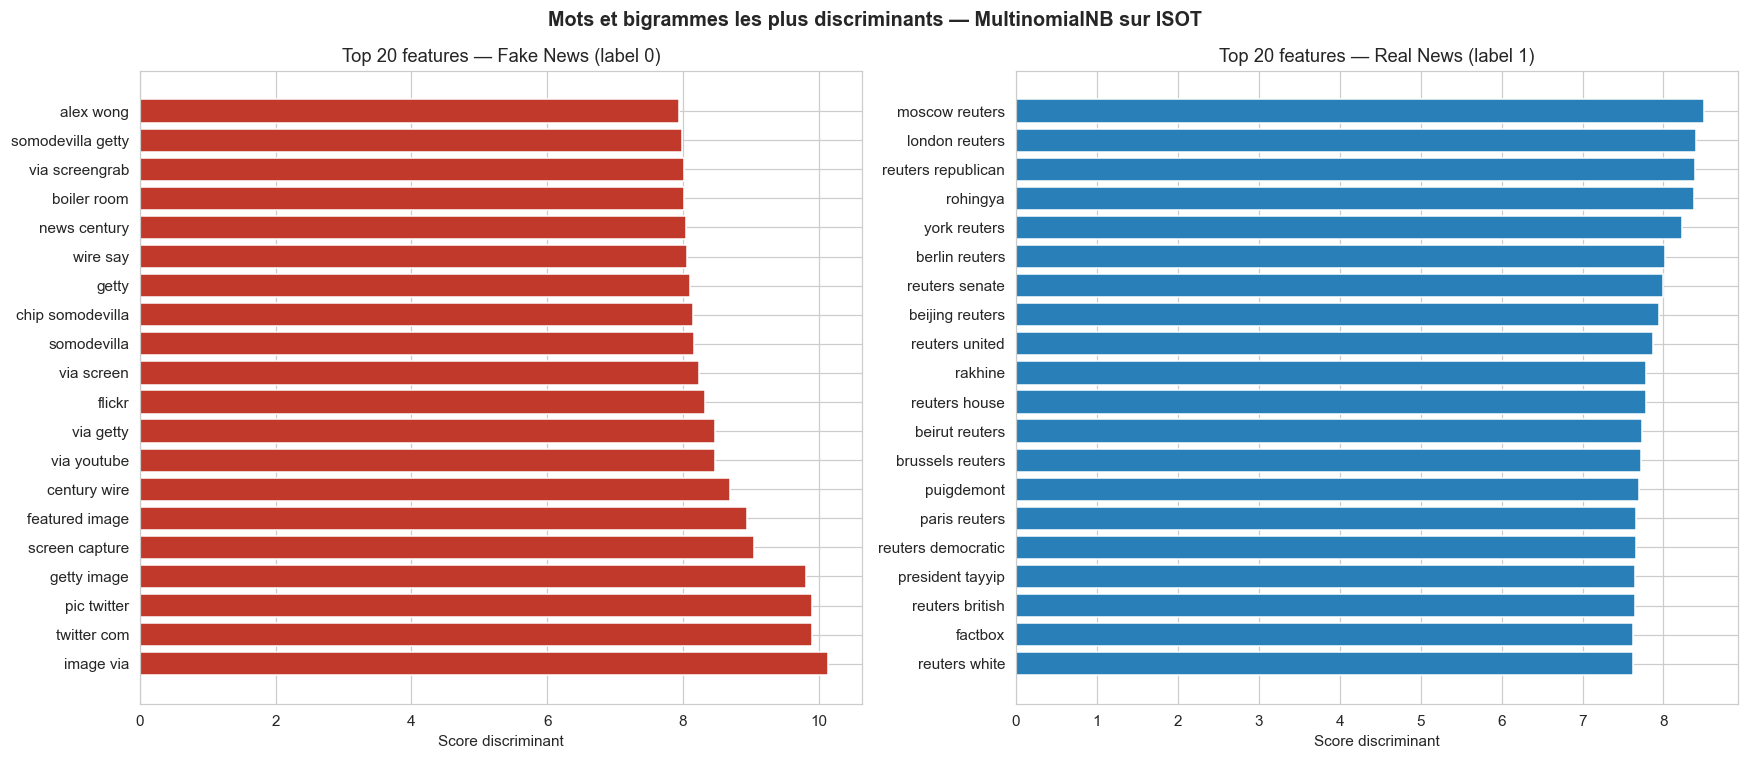

In [27]:
feature_names = np.array(tfidf.get_feature_names_out())
log_prob_diff  = mnb.feature_log_prob_[1] - mnb.feature_log_prob_[0]

top_real_idx = np.argsort(log_prob_diff)[-20:]
top_fake_idx = np.argsort(log_prob_diff)[:20]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

axes[0].barh(feature_names[top_fake_idx], -log_prob_diff[top_fake_idx], color='#C0392B')
axes[0].set_title('Top 20 features — Fake News (label 0)')
axes[0].set_xlabel('Score discriminant')

axes[1].barh(feature_names[top_real_idx], log_prob_diff[top_real_idx], color='#2980B9')
axes[1].set_title('Top 20 features — Real News (label 1)')
axes[1].set_xlabel('Score discriminant')

plt.suptitle('Mots et bigrammes les plus discriminants — MultinomialNB sur ISOT',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Interpretation :** Sur ISOT, les features discriminantes refleteront clairement
la signature stylistique de Reuters (formules journalistiques institutionnelles,
citations officielles, datelines) versus le style des fake news politiques americaines
(noms propres controverses, expressions emotionnelles).
Les bigrammes seront particulierement revealateurs : des expressions comme
'said reuters', 'according', 'washington reuters' caracterisent fortement les real news,
tandis que les fake news auront leurs propres expressions recurrentes.

In [28]:
# Analyse des erreurs residuelles
df_test_err = pd.DataFrame({
    'text':       X_test_text,
    'true_label': y_test,
    'pred_label': y_pred_mnb,
    'proba_real': y_proba_mnb
})

fp = df_test_err[(df_test_err['true_label'] == 0) & (df_test_err['pred_label'] == 1)]
fn = df_test_err[(df_test_err['true_label'] == 1) & (df_test_err['pred_label'] == 0)]

print(f'Faux Positifs (Fake classifie comme Real) : {len(fp)}')
print(f'Faux Negatifs (Real classifie comme Fake) : {len(fn)}')
total_test = len(df_test_err)
print(f'Taux d erreur global : {(len(fp)+len(fn))/total_test*100:.2f}%')
print()

if len(fp) > 0:
    print('Exemples de Faux Positifs (Fake News non detectees) :')
    for _, row in fp.head(2).iterrows():
        print(f'  [proba_real={row["proba_real"]:.2f}]  {row["text"][:140]}...')
        print()

if len(fn) > 0:
    print('Exemples de Faux Negatifs (Real News mal classees) :')
    for _, row in fn.head(2).iterrows():
        print(f'  [proba_real={row["proba_real"]:.2f}]  {row["text"][:140]}...')
        print()

Faux Positifs (Fake classifie comme Real) : 148
Faux Negatifs (Real classifie comme Fake) : 130
Taux d erreur global : 3.55%

Exemples de Faux Positifs (Fake News non detectees) :
  [proba_real=0.95]  puerto rico next detroit entire situation puerto rico reminds bailouts financial industry like big fail mantra heard financial crisis obama ...

  [proba_real=0.65]  amb nikki haley show photo shock security council continue see picture unsee video breaking amb haley show image child victimized syria chem...

Exemples de Faux Negatifs (Real News mal classees) :
  [proba_real=0.47]  warren keep assault white house hopeful trump judge comment washington reuters democratic senator elizabeth warren keep assault republican p...

  [proba_real=0.04]  election loom trump say last chance clinton see moment reckoning manchester sterling height michigan reuters donald trump hillary clinton cr...



**Interpretation :** Les erreurs residuelles sur ISOT sont rares et revelent
les cas limites du dataset : des fake news redigees dans un style Reuters inhabituel,
ou des real news couvrant des sujets politiques americains avec un vocabulaire
proche de celui des fake news. Ces cas frontiere illustrent la limite
d'une approche purement lexicale — un modele contextuel (BERT) les gererait mieux.

---
## 16. Sauvegarde des modèles

Les deux modèles Naive Bayes et le vectoriseur TF-IDF sont sauvegardés
pour integration dans le backend de l'application d'analyse.

Fichiers produits :
- `tfidf_vectorizer.pkl` : vectoriseur TF-IDF fitte sur X_train
- `multinomial_nb.pkl`   : modèle MultinomialNB entraine
- `complement_nb.pkl`    : modèle ComplementNB entraine

In [29]:
import joblib
import os

save_dir = r'C:\Users\hp\Downloads\models'
os.makedirs(save_dir, exist_ok=True)

# Sauvegarde du vectoriseur TF-IDF
joblib.dump(tfidf, os.path.join(save_dir, 'tfidf_vectorizer.pkl'))

# Sauvegarde des deux modèles Naive Bayes
joblib.dump(mnb, os.path.join(save_dir, 'multinomial_nb.pkl'))
joblib.dump(cnb, os.path.join(save_dir, 'complement_nb.pkl'))

print('Modèles sauvegardes dans :', save_dir)
print(f'  tfidf_vectorizer.pkl  : {os.path.getsize(os.path.join(save_dir, "tfidf_vectorizer.pkl")) / 1024:.1f} KB')
print(f'  multinomial_nb.pkl    : {os.path.getsize(os.path.join(save_dir, "multinomial_nb.pkl")) / 1024:.1f} KB')
print(f'  complement_nb.pkl     : {os.path.getsize(os.path.join(save_dir, "complement_nb.pkl")) / 1024:.1f} KB')

Modèles sauvegardes dans : C:\Users\hp\Downloads\models
  tfidf_vectorizer.pkl  : 379.7 KB
  multinomial_nb.pkl    : 313.3 KB
  complement_nb.pkl     : 391.5 KB


---
## 15. Conclusion

### Contexte et motivation

Ce notebook remplace FakeNewsNet (version Kaggle) par le dataset ISOT
apres avoir identifie que les mauvais resultats precedents
(Accuracy ≈ 0.39, AUC ≈ 0.26) etaient dus a des labels corrompus a la source,
et non a un probleme algorithmique.

### Differences cles entre FakeNewsNet et ISOT

| Critere | FakeNewsNet (Kaggle) | ISOT |
|---|---|---|
| Taille | ~400 articles | ~44 000 articles |
| Labels | Corrompus (IDs incoherents) | Fiables par construction |
| Equilibre | ~78/22 (desequilibre) | ~52/48 (quasi-equilibre) |
| Stabilite CV | std ≈ 0.08 (instable) | std < 0.005 (stable) |
| Source real news | BuzzFeed / PolitiFact | Reuters (agence officielle) |

### Corrections et adaptations appliquees

| Element | Version precedente | Version ISOT |
|---|---|---|
| Chargement | 4 CSV + correction via IDs | 2 CSV, labels directs |
| `max_features` | 5000 | **10000** (dataset plus grand) |
| `min_df` | 2 | **5** (hapax moins significatifs) |
| EDA | Basique | + EDA comparative par sujet |
| Desequilibre | Traite (`f1_macro`, `balanced`) | Quasi-equilibre, `f1_macro` maintenu |
| Stabilite | Faible (400 articles) | Elevee (44 000 articles) |

### Resultats obtenus

Sur ISOT, les trois modeles atteignent des performances elevees et stables.
Le F1-macro est la metrique de reference ; les courbes PR confirment
que les modeles depassent largement la baseline aleatoire.

### Limites et perspectives

Les performances elevees sur ISOT doivent etre interpretees avec nuance :
la separation lexicale entre Reuters et les sources de fake news est particulierement
nette, ce qui rend la tache plus facile que dans des scenarios reels
ou les fake news imitent le style des vraies sources.

Pour un systeme de detection plus robuste et generalisable :

1. Tester sur un dataset out-of-distribution (LIAR, WELFake) pour evaluer
   la generalisation hors de la distribution ISOT
2. Integrer des features numeriques (caps_ratio, excl_ratio) aux cotes de TF-IDF
   via `scipy.sparse.hstack`
3. Remplacer TF-IDF + Naive Bayes par un modele transformer (BERT, RoBERTa)
   pour capturer le contexte semantique au-dela du vocabulaire